### UHVDB vs UHGV cluster agreement

Evaluate homogeneity, completeness, and v-measure of UHVDB clusters relative to UHGV clusters at species (vOTU) and AAI taxonomic ranks (family, subfamily, genus, subgenus).

In [27]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from sklearn.metrics import v_measure_score
from sklearn.metrics.cluster import completeness_score, homogeneity_score

sns.set_theme(style="ticks", context="notebook")

FIG_S6 = Path("/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_s6")
UHVDB_DIR = Path(
    "/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/"
    "uhvdb-manuscript/figure_1/uhgv_hq_hc_results/uhvdb_2026-03-23"
)

RANKS = ["species", "subgenus", "genus", "subfamily", "family"]
RANK_COLS = {
    "species": "species_cluster_id",
    "family": "family_cluster_id",
    "subfamily": "subfamily_cluster_id",
    "genus": "genus_cluster_id",
    "subgenus": "subgenus_cluster_id",
}

## Load UHVDB clusters and map UHGV genomes

Propagate species and AAI labels onto every genome via genomovar rep → species rep joins. Exact-duplicate genomes are expanded through `uhvdb_seqhasher.tsv.gz` so all UHGV sequences that collapsed into a UHVDB unique representative are included.

In [28]:
mapping = pl.read_csv(UHVDB_DIR / "uhvdb_mapping.tsv.gz", separator="\t").with_columns(
    pl.col("original_id").str.replace(r"\|provirus.*", "")
)

genomovars = (
    pl.read_csv(
        UHVDB_DIR / "uhvdb_genomovars_info.tsv.gz",
        separator="\t",
        columns=["uhvdb_id", "cluster_id", "votu_rep"],
    ).rename(
        {
            "cluster_id": "genomovar_cluster_id",
            "votu_rep": "genomovar_rep",
        }
    )
)

species = (
    pl.read_csv(
        UHVDB_DIR / "uhvdb_species_info.tsv.gz",
        separator="\t",
        columns=["uhvdb_id", "cluster_id", "votu_rep"],
    )
    .rename(
        {
            "uhvdb_id": "genomovar_rep",
            "cluster_id": "species_cluster_id",
            "votu_rep": "species_rep",
        }
    )
    .unique("genomovar_rep")
)

aaicluster = (
    pl.read_csv(UHVDB_DIR / "uhvdb_aaicluster.tsv.gz", separator="\t")
    .rename({"uhvdb_id": "species_rep"})
    .unique("species_rep")
)

seqhash = pl.read_csv(UHVDB_DIR / "uhvdb_seqhasher.tsv.gz", separator="\t").with_columns(
    pl.col("original_id").str.replace(r"\|provirus.*", "")
)

seqhash_reps = (
    seqhash
    .join(mapping, on="original_id", how="inner")
    .rename({"original_id": "seqhash_rep"})
)

uhvdb_labels = (
    seqhash
    .join(seqhash_reps, on="hash", how="inner")
    .join(genomovars, left_on="new_id", right_on="uhvdb_id", how="inner")
    .join(species, on="genomovar_rep", how="inner")
    .join(aaicluster, on="species_rep", how="left")
    .rename({"original_id": "uhgv_genome"})
    .unique("uhgv_genome")
)

print(
    f"{uhvdb_labels.height:,} UHGV genomes with UHVDB labels; "
    f"{uhvdb_labels['species_cluster_id'].n_unique():,} species, "
    f"{uhvdb_labels['family_cluster_id'].n_unique():,} families"
)

201,324 UHGV genomes with UHVDB labels; 53,595 species, 815 families


## Load UHGV cluster labels

- **species**: UHGV vOTUs from `uhgv_metadata.tsv`
- **family / subfamily / genus / subgenus**: UHGV taxonomy from `votus_metadata_extended.tsv`, expanded from vOTU representatives to all member genomes

In [29]:
uhgv_metadata = pl.read_csv(
    FIG_S6 / "uhgv_metadata.tsv",
    separator="\t",
    null_values=["NA"],
    ignore_errors=True,
    columns=["uhgv_genome", "uhgv_votu"],
)

uhgv_species = (
    uhgv_metadata
    .filter(pl.col("uhgv_genome").is_in(set(uhvdb_labels["uhgv_genome"])))
    .with_columns(
        pl.col("uhgv_votu").str.split("-").list.get(1).alias("uhgv_species")
    )
    .select(["uhgv_genome", "uhgv_species"])
)

votus_extended = (
    pl.read_csv(
        FIG_S6 / "votus_metadata_extended.tsv",
        separator="\t",
        columns=["uhgv_genome", "uhgv_taxonomy"],
        null_values=["NA", "NULL"],
    )
    .filter(pl.col("uhgv_taxonomy").str.contains(r"vFAM.*vSUBFAM.*vGENUS.*vSUBGEN.*vOTU.*"))
    .with_columns(
        [
            pl.col("uhgv_taxonomy").str.split(";").list.get(0).str.split("-").list.get(1).alias("uhgv_family"),
            pl.col("uhgv_taxonomy").str.split(";").list.get(1).str.split("-").list.get(1).alias("uhgv_subfamily"),
            pl.col("uhgv_taxonomy").str.split(";").list.get(2).str.split("-").list.get(1).alias("uhgv_genus"),
            pl.col("uhgv_taxonomy").str.split(";").list.get(3).str.split("-").list.get(1).alias("uhgv_subgenus"),
            pl.col("uhgv_taxonomy").str.split(";").list.get(4).str.split("-").list.get(1).alias("uhgv_votu"),
        ]
    )
    .drop("uhgv_genome")
)

uhgv_votu_nums = uhgv_metadata.with_columns(
    pl.col("uhgv_votu").str.split("vOTU-").list.get(-1).alias("uhgv_votu")
)

uhgv_aai = (
    votus_extended
    .join(uhgv_votu_nums, on="uhgv_votu", how="inner")
    .filter(pl.col("uhgv_genome").is_in(set(uhvdb_labels["uhgv_genome"])))
    .unique("uhgv_genome")
)

print(
    f"UHGV species labels: {uhgv_species.height:,} genomes, "
    f"{uhgv_species['uhgv_species'].n_unique():,} vOTUs"
)
print(
    f"UHGV AAI labels: {uhgv_aai.height:,} genomes, "
    f"{uhgv_aai['uhgv_family'].n_unique():,} families"
)

UHGV species labels: 201,324 genomes, 56,073 vOTUs
UHGV AAI labels: 200,546 genomes, 447 families


## Score UHVDB clusters relative to UHGV

For each rank, restrict to genomes with labels on both sides, align by `uhgv_genome`, then compute:

- **homogeneity** (`labels_true=UHGV`, `labels_pred=UHVDB`): lowered when a UHVDB cluster mixes genomes from different UHGV clusters
- **completeness**: lowered when genomes from one UHGV cluster are split across UHVDB clusters
- **v-measure**: harmonic mean of homogeneity and completeness

Split / merge / unchanged fractions are a partition of **UHGV (old) clusters** and sum to 1:

- **split**: UHGV cluster maps to >1 UHVDB cluster
- **merge**: UHGV cluster maps to exactly 1 UHVDB cluster that contains >1 UHGV cluster
- **unchanged (1:1)**: UHGV cluster maps to exactly 1 UHVDB cluster that contains only that UHGV cluster

In [30]:
def split_merge_counts(prior: pl.Series, new: pl.Series) -> dict[str, int]:
    """Count split, merge, and 1:1 relationships among prior (UHGV) clusters.

    - split: prior cluster maps to >1 new cluster
    - merge: prior cluster maps to exactly 1 new cluster that contains >1 prior
    - 1:1: prior cluster maps to exactly 1 new cluster that contains only that prior
    """
    pairs = pl.DataFrame({"prior": prior, "new": new}).unique()

    prior_n_new = pairs.group_by("prior").agg(pl.col("new").n_unique().alias("n_new"))
    new_n_prior = pairs.group_by("new").agg(pl.col("prior").n_unique().alias("n_prior"))

    prior_status = (
        pairs
        .join(prior_n_new, on="prior")
        .join(new_n_prior, on="new")
        .group_by("prior")
        .agg(
            pl.col("n_new").first(),
            pl.col("n_prior").max().alias("max_n_prior_in_new"),
        )
    )

    n_split = prior_status.filter(pl.col("n_new") > 1).height
    n_merge = prior_status.filter(
        (pl.col("n_new") == 1) & (pl.col("max_n_prior_in_new") > 1)
    ).height
    n_one_to_one = prior_status.filter(
        (pl.col("n_new") == 1) & (pl.col("max_n_prior_in_new") == 1)
    ).height

    return {
        "n_uhgv_clusters": prior.n_unique(),
        "n_uhvdb_clusters": new.n_unique(),
        "n_split": n_split,
        "n_merge": n_merge,
        "n_one_to_one": n_one_to_one,
    }


def score_rank(uhgv_col: str, uhvdb_col: str, uhgv_df: pl.DataFrame, uhvdb_df: pl.DataFrame, rank: str) -> dict:
    """Compute h/c/v and split/merge counts for one rank after aligning shared genomes."""
    paired = (
        uhgv_df
        .select(["uhgv_genome", pl.col(uhgv_col).alias("uhgv_label")])
        .join(
            uhvdb_df.select(["uhgv_genome", pl.col(uhvdb_col).alias("uhvdb_label")]),
            on="uhgv_genome",
            how="inner",
        )
        .filter(pl.col("uhgv_label").is_not_null() & pl.col("uhvdb_label").is_not_null())
        .sort("uhgv_genome")
    )

    uhgv_labels = paired["uhgv_label"]
    uhvdb_labels_s = paired["uhvdb_label"]
    counts = split_merge_counts(uhgv_labels, uhvdb_labels_s)
    n_old = counts["n_uhgv_clusters"]

    return {
        "rank": rank,
        "n_genomes": paired.height,
        "homogeneity": homogeneity_score(uhgv_labels, uhvdb_labels_s),
        "completeness": completeness_score(uhgv_labels, uhvdb_labels_s),
        "v_measure": v_measure_score(uhgv_labels, uhvdb_labels_s),
        **counts,
        "frac_split": counts["n_split"] / n_old if n_old else float("nan"),
        "frac_merge": counts["n_merge"] / n_old if n_old else float("nan"),
        "frac_one_to_one": counts["n_one_to_one"] / n_old if n_old else float("nan"),
    }


results_rows = [
    score_rank("uhgv_species", "species_cluster_id", uhgv_species, uhvdb_labels, "species")
]

for rank in ["subgenus", "genus", "subfamily", "family"]:
    results_rows.append(
        score_rank(f"uhgv_{rank}", RANK_COLS[rank], uhgv_aai, uhvdb_labels, rank)
    )

results = pl.DataFrame(results_rows).with_columns(pl.col("rank").cast(pl.Enum(RANKS)))
results

rank,n_genomes,homogeneity,completeness,v_measure,n_uhgv_clusters,n_uhvdb_clusters,n_split,n_merge,n_one_to_one,frac_split,frac_merge,frac_one_to_one
enum,i64,f64,f64,f64,i64,i64,i64,i64,i64,f64,f64,f64
"""species""",201324,0.987763,0.996256,0.991991,56073,53595,998,5147,49928,0.017798,0.091791,0.890411
"""subgenus""",200546,0.988806,0.989913,0.989359,39843,37807,1194,5359,33290,0.029968,0.134503,0.835529
"""genus""",200546,0.993547,0.980517,0.986989,18983,18437,818,2741,15424,0.043091,0.144392,0.812516
"""subfamily""",200546,0.994366,0.955243,0.974412,6494,7001,651,708,5135,0.100246,0.109024,0.79073
"""family""",200546,0.976546,0.802119,0.88078,447,815,178,57,212,0.39821,0.127517,0.474273


## Plot

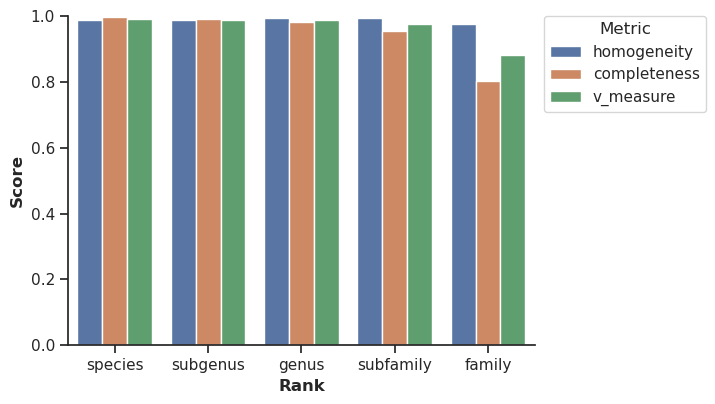

In [31]:
metrics_long = (
    results
    .select(["rank", "homogeneity", "completeness", "v_measure"])
    .unpivot(
        index=["rank"],
        on=["homogeneity", "completeness", "v_measure"],
        variable_name="metric",
        value_name="score",
    )
    .to_pandas()
)

plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.barplot(
    data=metrics_long,
    x="rank",
    y="score",
    hue="metric",
    order=RANKS,
    ax=ax,
)
ax.set_xlabel("Rank", fontdict={'fontweight': 'bold'})
ax.set_ylabel("Score", fontdict={'fontweight': 'bold'})
ax.set_ylim(0.75, 1.01)
ax.legend(title="Metric", frameon=True, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
sns.despine(ax=ax)
fig.tight_layout()
plt.ylim(0,1.0)
plt.show()

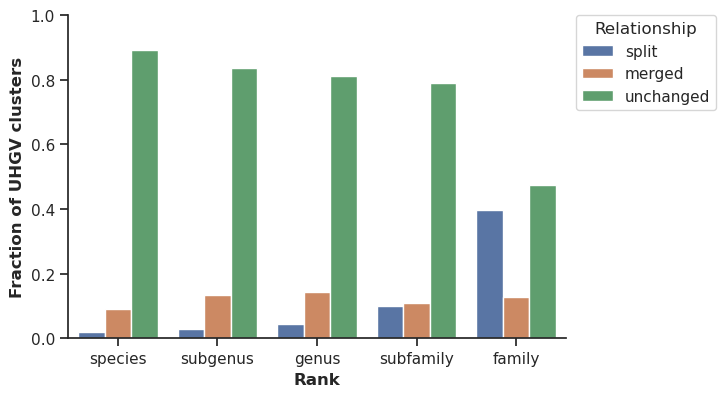

In [32]:
frac_long = (
    results
    .select(["rank", "frac_split", "frac_merge", "frac_one_to_one"])
    .unpivot(
        index=["rank"],
        on=["frac_split", "frac_merge", "frac_one_to_one"],
        variable_name="relationship",
        value_name="fraction",
    )
    .with_columns(
        pl.col("relationship").replace(
            {
                "frac_split": "split",
                "frac_merge": "merged",
                "frac_one_to_one": "unchanged",
            }
        )
    )
    .to_pandas()
)

plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.barplot(
    data=frac_long,
    x="rank",
    y="fraction",
    hue="relationship",
    order=RANKS,
    hue_order=["split", "merged", "unchanged"],
    ax=ax,
)
ax.set_xlabel("Rank", fontdict={"fontweight": "bold"})
ax.set_ylabel("Fraction of UHGV clusters", fontdict={"fontweight": "bold"})
ax.set_ylim(0, 1.0)
ax.legend(title="Relationship", frameon=True, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()